# 加载数据

In [16]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import statsmodels.formula.api as smf

from sklearn.preprocessing import LabelEncoder
from sklearn.feature_selection import SelectKBest
from sklearn.model_selection import train_test_split
from sklearn.model_selection import StratifiedKFold, KFold
from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import chi2
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Lasso
from sklearn.preprocessing import StandardScaler
import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostRegressor

# 评价指标
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, log_loss

plt.rcParams["font.sans-serif"]=["SimHei"]
plt.rcParams["axes.unicode_minus"]=False

# 训练集

## 训练集数据处理

In [178]:
df = pd.read_csv('train.csv')
df_cleaned = df.dropna()
# 3) 随机抽样：train 8w + test 2w（不重叠）
# =========================
random_state = 42

# 先抽 train 8w
df_0 = df_cleaned[df_cleaned["isDefault"] == 0]
df_1 = df_cleaned[df_cleaned["isDefault"] == 1]

# 检查样本是否足够
if len(df_0) < 60000:
    raise ValueError(f"isDefault=0 样本不足60000，当前仅 {len(df_0)}")
if len(df_1) < 40000:
    raise ValueError(f"isDefault=1 样本不足40000，当前仅 {len(df_1)}")

# 抽样并合并
train_df = pd.concat([
    df_0.sample(n=60000, random_state=random_state),
    df_1.sample(n=40000, random_state=random_state)
], axis=0)

# 打乱顺序
train_df = train_df.sample(frac=1, random_state=random_state).reset_index(drop=True)

# 从剩余数据中抽 test 2w
# remaining_df = df_cleaned.drop(index=train_df.index)
# test_df = remaining_df.sample(n=20000, random_state=random_state)

# （可选）重置索引
train_df = train_df.reset_index(drop=True)
# test_df = test_df.reset_index(drop=True)

# =========================
# 4) 计算比例函数
# =========================
def default_ratio(data, col="isDefault"):
    # value_counts(normalize=True) 返回占比
    ratio = data[col].value_counts(normalize=True).reindex([0, 1], fill_value=0)
    count = data[col].value_counts().reindex([0, 1], fill_value=0)
    result = pd.DataFrame({
        "count": count,
        "ratio": ratio,
        "ratio_percent": (ratio * 100).round(4)
    })
    return result

train_stat = default_ratio(train_df, "isDefault")
# test_stat = default_ratio(test_df, "isDefault")

# =========================
# 5) 打印结果
# =========================
print("=== Train (80000) 中 isDefault 分布 ===")
print(train_stat)
print()



=== Train (80000) 中 isDefault 分布 ===
           count  ratio  ratio_percent
isDefault                             
0          60000    0.6           60.0
1          40000    0.4           40.0



In [179]:
train_df["employmentLength"] = (
    train_df["employmentLength"]
    .astype(str)
    .str.lower()
    .str.replace("10+ years", "10", regex=False)
    .str.replace("< 1 year", "0.5", regex=False)
    .str.replace("years", "", regex=False)
    .str.replace("year", "", regex=False)
    .str.strip()
)

train_df["employmentLength"] = pd.to_numeric(train_df["employmentLength"], errors="coerce")

In [180]:
train_df["employmentLength"].head(10)

0     9.0
1     5.0
2    10.0
3     8.0
4     4.0
5     0.5
6     7.0
7    10.0
8    10.0
9     2.0
Name: employmentLength, dtype: float64

In [181]:
##级别
a2z = 'ABCDEFGHIJKLMNOPQRSTUVWXYZ'
a2z_code = np.arange(1, 27)
a2z_mapping = dict(zip(a2z, a2z_code))

for data in [train_df]:
    data.loc[:, ['grade', 'subGrade']] = data.loc[:, ['grade', 'subGrade']].astype(str).applymap(
        lambda g: g.replace(g[0], str(a2z.index(g[0]) + 1)) if g[0] in a2z else g
    ).astype('int')

In [182]:
# For issueDate

import datetime

# 处理 'issueDate' 列，转换为日期格式
train_df['issueDate'] = pd.to_datetime(train_df['issueDate'], format='%Y-%m-%d')
train_df['issueDate_year'] = train_df['issueDate'].dt.year  # 提取年份

# 处理 'earliesCreditLine' 列，假设格式为 'May-1992'
train_df['earliesCreditLine'] = pd.to_datetime(train_df['earliesCreditLine'], format='%b-%Y', errors='coerce')  # 处理可能的错误
train_df['earliesCreditLine_year'] = train_df['earliesCreditLine'].dt.year  # 提取年份

# 计算 'CreditLine' 为 'issueDate_year' 和 'earliesCreditLine_year' 之差
train_df['CreditLine'] = train_df['issueDate_year'] - train_df['earliesCreditLine_year']

# 删除 'earliesCreditLine' 和 'issueDate' 列
train_df = train_df.drop(['earliesCreditLine', 'issueDate'], axis=1)

# 查看结果
print(train_df[['issueDate_year', 'earliesCreditLine_year', 'CreditLine']].head())

   issueDate_year  earliesCreditLine_year  CreditLine
0            2016                    1986          30
1            2015                    2003          12
2            2015                    2007           8
3            2015                    1993          22
4            2015                    1995          20


In [183]:
##创建衍生变量
for data in [train_df]:
    data['avg_income'] = data['annualIncome'] / data['employmentLength']
    data['total_income'] = data['annualIncome'] * data['employmentLength']
    data['avg_loanAmnt'] = data['loanAmnt'] / data['term']
    data['mean_interestRate'] = data['interestRate'] / data['term']
    data['all_installment'] = data['installment'] * data['term']

    data['rest_money_rate'] = data['avg_loanAmnt'] / (data['annualIncome'] + 0.1)  # 287个收入为0
    data['rest_money'] = data['annualIncome'] - data['avg_loanAmnt']

    data['closeAcc'] = data['totalAcc'] - data['openAcc']
    data['ficoRange_mean'] = (data['ficoRangeHigh'] + data['ficoRangeLow']) / 2

    data['rest_pubRec'] = data['pubRec'] - data['pubRecBankruptcies']
    data['rest_Revol'] = data['loanAmnt'] - data['revolBal']

In [184]:
print(train_binned_df.head())

       id  loanAmnt  term  interestRate  installment grade subGrade  \
0  745565    6500.0     3         16.24       229.30     3       35   
1  770865   10000.0     3         11.53       329.91     2       25   
2  297885    8000.0     3         19.72       296.17     4       45   
3  344979   35000.0     3          8.18      1099.69     2       21   
4  688195    5750.0     3         16.29       202.98     4       41   

   employmentTitle  employmentLength  homeOwnership  ...  loanAmnt_bin  \
0          65678.0               6.0              1  ...             1   
1           3376.0               1.0              0  ...             2   
2         218946.0              10.0              1  ...             1   
3             48.0               2.0              0  ...             6   
4           2670.0               2.0              1  ...             1   

   annualIncome_bin  ficoRange_mean_bin  dti_bin  openAcc_bin  revolBal_bin  \
0                 4                   1        5 

In [185]:
from sklearn.preprocessing import OneHotEncoder
oh = OneHotEncoder(sparse_output=False)
oh.fit(train_df[['homeOwnership','verificationStatus']])
OneHot1 = oh.transform(train_df[['homeOwnership','verificationStatus']])
OneHot1.shape
columns = oh.get_feature_names_out(['homeOwnership', 'verificationStatus'])
OneHot_df = pd.DataFrame(OneHot1, columns=columns)
print(OneHot_df.head())

   homeOwnership_0  homeOwnership_1  homeOwnership_2  homeOwnership_3  \
0              1.0              0.0              0.0              0.0   
1              0.0              1.0              0.0              0.0   
2              1.0              0.0              0.0              0.0   
3              0.0              1.0              0.0              0.0   
4              0.0              1.0              0.0              0.0   

   homeOwnership_4  homeOwnership_5  verificationStatus_0  \
0              0.0              0.0                   0.0   
1              0.0              0.0                   0.0   
2              0.0              0.0                   0.0   
3              0.0              0.0                   0.0   
4              0.0              0.0                   1.0   

   verificationStatus_1  verificationStatus_2  
0                   1.0                   0.0  
1                   1.0                   0.0  
2                   0.0                   1.0  
3 

In [186]:
from sklearn.model_selection import StratifiedKFold

def kfold_stats_feature(train_df, feats, k):
    folds = StratifiedKFold(n_splits=k, shuffle=True, random_state=6666)  # 这里最好和后面模型的K折交叉验证保持一致

    train_df['fold'] = None
    # 为每个样本分配一个fold
    for fold_, (trn_idx, val_idx) in enumerate(folds.split(train_df, train_df['isDefault'])):
        train_df.loc[val_idx, 'fold'] = fold_

    # 进行k-fold的目标编码
    kfold_features = []
    for feat in feats:
        nums_columns = ['isDefault']
        for f in nums_columns:
            colname = f'k-{feat}'  # 新的命名格式为 k-原始变量名称
            kfold_features.append(colname)
            train_df[colname] = None
            for fold_, (trn_idx, val_idx) in enumerate(folds.split(train_df, train_df['isDefault'])):
                tmp_trn = train_df.iloc[trn_idx]
                # 按特征分组并计算均值
                order_label = tmp_trn.groupby([feat])[f].mean() 
                tmp = train_df.loc[train_df.fold == fold_, [feat]]
                # 将目标编码填入对应的列
                train_df.loc[train_df.fold == fold_, colname] = tmp[feat].map(order_label)
                # 填充缺失值
                global_mean = train_df[f].mean()
                train_df.loc[train_df.fold == fold_, colname] = train_df.loc[train_df.fold == fold_, colname].fillna(global_mean)
            train_df[colname] = train_df[colname].astype(float)

    del train_df['fold']  # 删除fold列
    return train_df

# 对特定的列进行目标编码
target_encode_cols = ['postCode', 'regionCode', 'employmentTitle', 'title', 'purpose']
kfold_num = 5  # 5折交叉验证
train_df = kfold_stats_feature(train_df, target_encode_cols, kfold_num)

# 查看添加的新列
print(train_df[['postCode', 'k-postCode', 'regionCode', 'k-regionCode', 'employmentTitle', 'k-employmentTitle', 'title', 'k-title', 'purpose', 'k-purpose']].head())

   postCode  k-postCode  regionCode  k-regionCode  employmentTitle  \
0     419.0    0.258065          14      0.395005            148.0   
1     221.0    0.398089           8      0.391989          12548.0   
2     482.0    0.294118          32      0.406347             32.0   
3     132.0    0.361502          12      0.430136           3407.0   
4     195.0    0.448276          38      0.420966          48505.0   

   k-employmentTitle  title   k-title  purpose  k-purpose  
0           0.385965    0.0  0.422158        0   0.415986  
1           0.500000    0.0  0.422158        0   0.415986  
2           0.429681    8.0  0.392781        7   0.401544  
3           0.142857    4.0  0.357213        4   0.350267  
4           1.000000    6.0  0.417983        5   0.418937  


In [187]:
###输出该版本无热编码，目标编码带原始，时间变量保留
train_df.to_csv('trainall.csv', index=False)
#删时间没用的
train_df=train_df.drop(["id","policyCode",'issueDate_year', 'earliesCreditLine_year','ficoRangeHigh','ficoRangeLow'],axis=1) 
#用目标编码后的
train = train_df.drop(['postCode', 'regionCode', 'employmentTitle', 'title', 'purpose'],axis=1)

## 训练集变量筛选

In [37]:
# 获取与 'isDefault' 相关的列，并筛选相关性小于 0.01 的列
train.corr()["isDefault"].sort_values()
low_corr_01 = train.corr()["isDefault"][train.corr()["isDefault"].abs() < 0.01].sort_values()
print("相关性小于0.01的变量:")
print(low_corr_01)

相关性小于0.01的变量:
totalAcc            -0.007489
n8                  -0.006063
n11                 -0.005854
avg_income          -0.004807
avg_loanAmnt        -0.001661
n12                 -0.001453
n4                   0.007553
initialListStatus    0.007699
Name: isDefault, dtype: float64


In [188]:
train=train.drop(["totalAcc","avg_loanAmnt","avg_income","initialListStatus","n11","n12","n8","n4"],axis=1)

In [40]:
##相关性
# 显示相关性高于0.9的变量
def getHighRelatedFeatureDf(corr_matrix, corr_threshold):
    highRelatedFeatureDf = pd.DataFrame(corr_matrix[corr_matrix > corr_threshold].stack().reset_index())
    highRelatedFeatureDf.rename({'level_0': 'feature_x', 'level_1': 'feature_y', 0: 'corr'}, axis=1, inplace=True)
    highRelatedFeatureDf = highRelatedFeatureDf[highRelatedFeatureDf.feature_x != highRelatedFeatureDf.feature_y]
    highRelatedFeatureDf['feature_pair_key'] = highRelatedFeatureDf.loc[:, ['feature_x', 'feature_y']].apply(lambda r: '#'.join(np.sort(r.values)), axis=1)
    highRelatedFeatureDf.drop_duplicates(subset=['feature_pair_key'], inplace=True)
    highRelatedFeatureDf.drop(['feature_pair_key'], axis=1, inplace=True)
    return highRelatedFeatureDf

# 使用斯皮尔曼相关系数计算相关性矩阵
getHighRelatedFeatureDf(train.corr(method='spearman'), 0.9)

,feature_x,feature_y,corr
1,loanAmnt,installment,0.968558
2,loanAmnt,all_installment,0.985035
5,interestRate,grade,0.957729
6,interestRate,subGrade,0.984480
9,installment,all_installment,0.940814
12,grade,subGrade,0.972287
19,annualIncome,rest_money,0.997491
25,openAcc,n10,0.999121
34,n2,n3,1.000000
35,n2,n9,0.998304


In [189]:
train=train.drop(['installment','rest_money','openAcc','n10',"n2","n9"],axis=1)


In [190]:
trainLASSO = pd.concat([train, pd.DataFrame(OneHot1)], axis=1)
trainLASSO = trainLASSO.drop(['homeOwnership','verificationStatus'],axis=1)

In [43]:
from sklearn.linear_model import Lasso
from sklearn.preprocessing import StandardScaler
import pandas as pd

# 目标变量
y = trainLASSO['isDefault']  # 目标变量
# 特征变量
X = trainLASSO.drop(columns=['isDefault'])  # 特征变量
# 将列名转换为字符串格式
X.columns = X.columns.astype(str)
# 数据标准化
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
# 使用Lasso进行特征选择
lasso = Lasso(alpha=0.001)
lasso.fit(X_scaled, y)
# 输出被选择的特征
selected_features = X.columns[lasso.coef_ == 0]
print("Lasso Selected Features: ", selected_features)

Lasso Selected Features:  Index(['interestRate', 'grade', 'annualIncome', 'pubRecBankruptcies',
       'revolBal', 'applicationType', 'n0', 'n1', 'n7', 'mean_interestRate',
       'k-purpose', '2', '3', '4', '8'],
      dtype='object')


In [191]:
train=train.drop(['grade', 'mean_interestRate', 'pubRecBankruptcies', 'revolBal', 'annualIncome', 'n0','n1','n7', 'applicationType'],axis=1)
trainhot=trainLASSO.drop(['grade', 'mean_interestRate', 'pubRecBankruptcies', 'revolBal', 'annualIncome', 'n0','n1','n7', 'applicationType'],axis=1)

In [192]:
trainhot.shape

(100000, 37)

In [46]:
train.shape

(80000, 30)

In [193]:
train.to_csv('train30.csv', index=False) #无hot
trainhot.to_csv('trainhot37.csv', index=False)

In [194]:
train_df.to_csv('data8w.csv', index=False)

# 测试集

## 测试集数据处理

In [56]:

test_df["employmentLength"] = (
    train_df["employmentLength"]
    .astype(str)
    .str.lower()
    .str.replace("10+ years", "10", regex=False)
    .str.replace("< 1 year", "0.5", regex=False)
    .str.replace("years", "", regex=False)
    .str.replace("year", "", regex=False)
    .str.strip()
)

test_df["employmentLength"] = pd.to_numeric(test_df["employmentLength"], errors="coerce")

##级别
a2z = 'ABCDEFGHIJKLMNOPQRSTUVWXYZ'
a2z_code = np.arange(1, 27)
a2z_mapping = dict(zip(a2z, a2z_code))

for data in [test_df]:
    data.loc[:, ['grade', 'subGrade']] = data.loc[:, ['grade', 'subGrade']].astype(str).applymap(
        lambda g: g.replace(g[0], str(a2z.index(g[0]) + 1)) if g[0] in a2z else g
    ).astype('int')

# For issueDate

import datetime

# 处理 'issueDate' 列，转换为日期格式
test_df['issueDate'] = pd.to_datetime(test_df['issueDate'], format='%Y-%m-%d')
test_df['issueDate_year'] = test_df['issueDate'].dt.year  # 提取年份

# 处理 'earliesCreditLine' 列，假设格式为 'May-1992'
test_df['earliesCreditLine'] = pd.to_datetime(test_df['earliesCreditLine'], format='%b-%Y', errors='coerce')  # 处理可能的错误
test_df['earliesCreditLine_year'] = test_df['earliesCreditLine'].dt.year  # 提取年份

# 计算 'CreditLine' 为 'issueDate_year' 和 'earliesCreditLine_year' 之差
test_df['CreditLine'] = test_df['issueDate_year'] - test_df['earliesCreditLine_year']

# 删除 'earliesCreditLine' 和 'issueDate' 列
test_df = test_df.drop(['earliesCreditLine', 'issueDate'], axis=1)

##创建衍生变量
for data in [test_df]:
    data['avg_income'] = data['annualIncome'] / data['employmentLength']
    data['total_income'] = data['annualIncome'] * data['employmentLength']
    data['avg_loanAmnt'] = data['loanAmnt'] / data['term']
    data['mean_interestRate'] = data['interestRate'] / data['term']
    data['all_installment'] = data['installment'] * data['term']

    data['rest_money_rate'] = data['avg_loanAmnt'] / (data['annualIncome'] + 0.1)  # 287个收入为0
    data['rest_money'] = data['annualIncome'] - data['avg_loanAmnt']

    data['closeAcc'] = data['totalAcc'] - data['openAcc']
    data['ficoRange_mean'] = (data['ficoRangeHigh'] + data['ficoRangeLow']) / 2

    data['rest_pubRec'] = data['pubRec'] - data['pubRecBankruptcies']
    data['rest_Revol'] = data['loanAmnt'] - data['revolBal']

In [49]:
target = "isDefault"

# 你给出的连续变量
features = [
    "avg_income",
    "total_income",
    "avg_loanAmnt",
    "mean_interestRate",
    "all_installment",
    "rest_money_rate",
    "rest_money",
    "closeAcc",
    "rest_pubRec",
    "rest_Revol",
    
    "interestRate",
    "installment",
    "loanAmnt",
    "annualIncome",
    "ficoRange_mean",
    "dti",
    "openAcc",
    "revolBal",
    "revolUtil",
    "totalAcc",
    "employmentLength",
    "CreditLine"
]

# =========================
# 基础检查（基于 train_df）
# =========================
need_cols = features + [target]
missing_cols = [c for c in need_cols if c not in test_df.columns]
if missing_cols:
    raise ValueError(f"test_df 缺失列: {missing_cols}")

if not set(test_df[target].dropna().unique()).issubset({0, 1}):
    raise ValueError("isDefault 必须是二分类 0/1")

# =========================================================
# 1) 决策树自动分箱：得到切分点
# =========================================================
def tree_cut_points(x, y, max_leaf_nodes=6, min_samples_leaf=0.05, random_state=42):
    tmp = pd.DataFrame({"x": x, "y": y}).dropna()
    if tmp["x"].nunique() <= 1:
        return []

    X = tmp[["x"]].values
    Y = tmp["y"].values

    clf = DecisionTreeClassifier(
        criterion="entropy",
        max_leaf_nodes=max_leaf_nodes,
        min_samples_leaf=min_samples_leaf,
        random_state=random_state
    )
    clf.fit(X, Y)

    thresholds = clf.tree_.threshold
    cuts = sorted([t for t in thresholds if t != -2])

    final_cuts = []
    for c in cuts:
        if len(final_cuts) == 0 or abs(c - final_cuts[-1]) > 1e-8:
            final_cuts.append(float(c))
    return final_cuts

# =========================================================
# 2) 分箱 + WOE/IV
# =========================================================
def bin_stats_woe_iv(data, feature, target, cuts, bad=1, eps=1e-6):
    s = data[[feature, target]].copy()

    miss_mask = s[feature].isna()

    if len(cuts) == 0:
        s["bin"] = "(-inf, inf]"
    else:
        bins = [-np.inf] + sorted(cuts) + [np.inf]
        s["bin"] = pd.cut(s[feature], bins=bins, right=True, duplicates="drop").astype(str)

    s.loc[miss_mask, "bin"] = "MISSING"

    g = s.groupby("bin", dropna=False)[target].agg(
        total="count",
        bad_cnt=lambda z: (z == bad).sum()
    ).reset_index()

    g["good_cnt"] = g["total"] - g["bad_cnt"]
    g["bad_rate"] = g["bad_cnt"] / g["total"]

    total_bad = g["bad_cnt"].sum()
    total_good = g["good_cnt"].sum()

    g["bad_dist"] = (g["bad_cnt"] + eps) / (total_bad + eps * len(g))
    g["good_dist"] = (g["good_cnt"] + eps) / (total_good + eps * len(g))

    g["woe"] = np.log(g["good_dist"] / g["bad_dist"])
    g["iv_component"] = (g["good_dist"] - g["bad_dist"]) * g["woe"]

    iv = g["iv_component"].sum()

    def left_bound(bin_str):
        if bin_str == "MISSING":
            return np.inf
        try:
            return float(bin_str.split(",")[0].replace("(", "").replace("[", ""))
        except:
            return np.inf

    g["sort_key"] = g["bin"].apply(left_bound)
    g = g.sort_values("sort_key").drop(columns="sort_key").reset_index(drop=True)

    return g, iv, cuts

# =========================================================
# 3) 批量处理（基于 train_df）
# =========================================================
all_detail = []
iv_summary = []

MAX_LEAF_NODES = 6
MIN_SAMPLES_LEAF = 0.05

for fea in features:
    cuts = tree_cut_points(
        x=test_df[fea],
        y=test_df[target],
        max_leaf_nodes=MAX_LEAF_NODES,
        min_samples_leaf=MIN_SAMPLES_LEAF,
        random_state=42
    )

    detail, iv, final_cuts = bin_stats_woe_iv(test_df, fea, target, cuts, bad=1)

    detail.insert(0, "feature", fea)
    all_detail.append(detail)

    iv_summary.append({
        "feature": fea,
        "iv": iv,
        "n_bins_excl_missing": len(final_cuts) + 1 if len(final_cuts) > 0 else 1,
        "cut_points": final_cuts
    })

detail_df = pd.concat(all_detail, axis=0, ignore_index=True)
iv_df = pd.DataFrame(iv_summary).sort_values("iv", ascending=False).reset_index(drop=True)

# =========================================================
# 4) 输出与保存
# =========================================================
print("=== IV 汇总（按降序） ===")
print(iv_df)

print("\n=== 分箱明细（前50行示例） ===")
print(detail_df.head(50))

iv_df.to_csv("iv_summary_tree_binning_test.csv", index=False, encoding="utf-8-sig")
detail_df.to_csv("bin_detail_tree_woe_iv_test.csv", index=False, encoding="utf-8-sig")

print("\n已保存文件：")
print("1) iv_summary_tree_binning_test.csv")
print("2) bin_detail_tree_woe_iv_test.csv")

=== IV 汇总（按降序） ===
              feature        iv  n_bins_excl_missing  \
0        interestRate  0.482398                    6   
1   mean_interestRate  0.214155                    6   
2      ficoRange_mean  0.104297                    6   
3     all_installment  0.092504                    6   
4                 dti  0.086321                    6   
5          rest_Revol  0.069892                    6   
6     rest_money_rate  0.052514                    6   
7        avg_loanAmnt  0.050661                    6   
8         installment  0.047038                    6   
9          rest_money  0.046627                    6   
10           loanAmnt  0.044680                    6   
11       annualIncome  0.043253                    6   
12         CreditLine  0.023296                    6   
13          revolUtil  0.020340                    6   
14       total_income  0.017906                    6   
15         avg_income  0.017003                    6   
16           closeAcc  0.0158

In [57]:
from sklearn.preprocessing import OneHotEncoder
oh = OneHotEncoder(sparse_output=False)
oh.fit(test_df[['homeOwnership','verificationStatus']])
OneHot1 = oh.transform(test_df[['homeOwnership','verificationStatus']])
OneHot1.shape
columns = oh.get_feature_names_out(['homeOwnership', 'verificationStatus'])
OneHot_df = pd.DataFrame(OneHot1, columns=columns)
print(OneHot_df.head())

   homeOwnership_0  homeOwnership_1  homeOwnership_2  homeOwnership_3  \
0              1.0              0.0              0.0              0.0   
1              0.0              1.0              0.0              0.0   
2              1.0              0.0              0.0              0.0   
3              1.0              0.0              0.0              0.0   
4              1.0              0.0              0.0              0.0   

   homeOwnership_5  verificationStatus_0  verificationStatus_1  \
0              0.0                   0.0                   0.0   
1              0.0                   1.0                   0.0   
2              0.0                   0.0                   0.0   
3              0.0                   0.0                   0.0   
4              0.0                   0.0                   0.0   

   verificationStatus_2  
0                   1.0  
1                   0.0  
2                   1.0  
3                   1.0  
4                   1.0  


In [58]:
from sklearn.model_selection import StratifiedKFold

def kfold_stats_feature(test_df, feats, k):
    folds = StratifiedKFold(n_splits=k, shuffle=True, random_state=6666)  # 这里最好和后面模型的K折交叉验证保持一致

    test_df['fold'] = None
    # 为每个样本分配一个fold
    for fold_, (trn_idx, val_idx) in enumerate(folds.split(test_df, test_df['isDefault'])):
        train_df.loc[val_idx, 'fold'] = fold_

    # 进行k-fold的目标编码
    kfold_features = []
    for feat in feats:
        nums_columns = ['isDefault']
        for f in nums_columns:
            colname = f'k-{feat}'  # 新的命名格式为 k-原始变量名称
            kfold_features.append(colname)
            test_df[colname] = None
            for fold_, (trn_idx, val_idx) in enumerate(folds.split(test_df, test_df['isDefault'])):
                tmp_trn = test_df.iloc[trn_idx]
                # 按特征分组并计算均值
                order_label = tmp_trn.groupby([feat])[f].mean() 
                tmp = test_df.loc[train_df.fold == fold_, [feat]]
                # 将目标编码填入对应的列
                test_df.loc[train_df.fold == fold_, colname] = tmp[feat].map(order_label)
                # 填充缺失值
                global_mean = train_df[f].mean()
                test_df.loc[test_df.fold == fold_, colname] = test_df.loc[test_df.fold == fold_, colname].fillna(global_mean)
            test_df[colname] = test_df[colname].astype(float)

    del test_df['fold']  # 删除fold列
    return test_df

# 对特定的列进行目标编码
target_encode_cols = ['postCode', 'regionCode', 'employmentTitle', 'title', 'purpose']
kfold_num = 5  # 5折交叉验证
test_df = kfold_stats_feature(test_df, target_encode_cols, kfold_num)

# 查看添加的新列
print(test_df[['postCode', 'k-postCode', 'regionCode', 'k-regionCode', 'employmentTitle', 'k-employmentTitle', 'title', 'k-title', 'purpose', 'k-purpose']].head())

   postCode  k-postCode  regionCode  k-regionCode  employmentTitle  \
0      31.0    0.179856           2      0.181534         372473.0   
1      54.0    0.140000          28      0.155844             90.0   
2     230.0    0.250000           2      0.195793             54.0   
3     266.0    0.105263          31      0.106383             38.0   
4     418.0    0.186441          45      0.156522            307.0   

   k-employmentTitle  title   k-title  purpose  k-purpose  
0                NaN    0.0  0.213323        0   0.209777  
1           0.142857    0.0  0.213323        0   0.209777  
2           0.259819    0.0  0.214668        0   0.210350  
3           0.144981    4.0  0.183214        4   0.178520  
4           0.090909    0.0  0.214668        0   0.210350  


## 删除测试集变量

In [59]:
test_df1=test_df.drop(["id","policyCode",'issueDate_year', 'earliesCreditLine_year','ficoRangeHigh','ficoRangeLow'],axis=1) 
#用目标编码后的
test_df2 = test_df1.drop(['postCode', 'regionCode', 'employmentTitle', 'title', 'purpose'],axis=1)

test=test_df2.drop(["totalAcc","avg_loanAmnt","avg_income","initialListStatus","n11","n12","n8","n4"],axis=1)
test1=test.drop(['installment','rest_money','openAcc','n10',"n2","n9"],axis=1)

testLASSO = pd.concat([test1, pd.DataFrame(OneHot1)], axis=1)
testLASSO = testLASSO.drop(['homeOwnership','verificationStatus'],axis=1)
test2=test1.drop(['grade', 'mean_interestRate', 'pubRecBankruptcies', 'revolBal', 'annualIncome', 'n0','n1','n7', 'applicationType'],axis=1)
testhot=testLASSO.drop(['grade', 'mean_interestRate', 'pubRecBankruptcies', 'revolBal', 'annualIncome', 'n0','n1','n7', 'applicationType'],axis=1)



In [66]:
print(test2.columns.tolist())

['loanAmnt', 'term', 'interestRate', 'subGrade', 'employmentLength', 'homeOwnership', 'verificationStatus', 'isDefault', 'dti', 'delinquency_2years', 'pubRec', 'revolUtil', 'n3', 'n5', 'n6', 'n13', 'n14', 'CreditLine', 'total_income', 'all_installment', 'rest_money_rate', 'closeAcc', 'ficoRange_mean', 'rest_pubRec', 'rest_Revol', 'k-postCode', 'k-regionCode', 'k-employmentTitle', 'k-title', 'k-purpose']


In [67]:
print(train.columns.tolist())

['loanAmnt', 'term', 'interestRate', 'subGrade', 'employmentLength', 'homeOwnership', 'verificationStatus', 'isDefault', 'dti', 'delinquency_2years', 'pubRec', 'revolUtil', 'n3', 'n5', 'n6', 'n13', 'n14', 'CreditLine', 'total_income', 'all_installment', 'rest_money_rate', 'closeAcc', 'ficoRange_mean', 'rest_pubRec', 'rest_Revol', 'k-postCode', 'k-regionCode', 'k-employmentTitle', 'k-title', 'k-purpose']


In [70]:
print(testhot.columns.tolist())

['loanAmnt', 'term', 'interestRate', 'subGrade', 'employmentLength', 'isDefault', 'dti', 'delinquency_2years', 'pubRec', 'revolUtil', 'n3', 'n5', 'n6', 'n13', 'n14', 'CreditLine', 'total_income', 'all_installment', 'rest_money_rate', 'closeAcc', 'ficoRange_mean', 'rest_pubRec', 'rest_Revol', 'k-postCode', 'k-regionCode', 'k-employmentTitle', 'k-title', 'k-purpose', 0, 1, 2, 3, 4, 5, 6, 7]


In [71]:
print(trainhot.columns.tolist())

['loanAmnt', 'term', 'interestRate', 'subGrade', 'employmentLength', 'isDefault', 'dti', 'delinquency_2years', 'pubRec', 'revolUtil', 'n3', 'n5', 'n6', 'n13', 'n14', 'CreditLine', 'total_income', 'all_installment', 'rest_money_rate', 'closeAcc', 'ficoRange_mean', 'rest_pubRec', 'rest_Revol', 'k-postCode', 'k-regionCode', 'k-employmentTitle', 'k-title', 'k-purpose', 0, 1, 2, 3, 4, 5, 6, 7, 8]


In [73]:
trainhot = trainhot.drop([8])

In [74]:
print(trainhot.columns.tolist())

['loanAmnt', 'term', 'interestRate', 'subGrade', 'employmentLength', 'isDefault', 'dti', 'delinquency_2years', 'pubRec', 'revolUtil', 'n3', 'n5', 'n6', 'n13', 'n14', 'CreditLine', 'total_income', 'all_installment', 'rest_money_rate', 'closeAcc', 'ficoRange_mean', 'rest_pubRec', 'rest_Revol', 'k-postCode', 'k-regionCode', 'k-employmentTitle', 'k-title', 'k-purpose', 0, 1, 2, 3, 4, 5, 6, 7, 8]


In [ ]:
trainhot.to_csv('trainhot36.csv', index=False)

In [69]:
testhot.shape

(20000, 36)

In [68]:
test2.shape

(20000, 30)

In [62]:
test.to_csv('test30.csv', index=False)
testhot.to_csv('testhot37.csv', index=False)

# 模型训练

In [9]:
# 假设 'train' 和 'train20w' 数据集都已经加载，并且它们的行是对齐的
data8w= pd.read_csv('data8w.csv')
data35= pd.read_csv('train30.csv')
columns_to_add = ['postCode', 'regionCode', 'employmentTitle', 'title', 'purpose']

# 将每一列从 'train20w' 添加到 'train' 中
for col in columns_to_add:
   data35[col] = data8w[col]

# 打印一下新的 train 数据集
data35.shape

(100000, 35)

In [10]:
print(data35.columns.tolist())

['loanAmnt', 'term', 'interestRate', 'subGrade', 'employmentLength', 'homeOwnership', 'verificationStatus', 'isDefault', 'dti', 'delinquency_2years', 'pubRec', 'revolUtil', 'n3', 'n5', 'n6', 'n13', 'n14', 'CreditLine', 'total_income', 'all_installment', 'rest_money_rate', 'closeAcc', 'ficoRange_mean', 'rest_pubRec', 'rest_Revol', 'k-postCode', 'k-regionCode', 'k-employmentTitle', 'k-title', 'k-purpose', 'postCode', 'regionCode', 'employmentTitle', 'title', 'purpose']


In [11]:
data30= pd.read_csv('trainhot37.csv')

In [12]:
print(data30.columns.tolist())

['loanAmnt', 'term', 'interestRate', 'subGrade', 'employmentLength', 'isDefault', 'dti', 'delinquency_2years', 'pubRec', 'revolUtil', 'n3', 'n5', 'n6', 'n13', 'n14', 'CreditLine', 'total_income', 'all_installment', 'rest_money_rate', 'closeAcc', 'ficoRange_mean', 'rest_pubRec', 'rest_Revol', 'k-postCode', 'k-regionCode', 'k-employmentTitle', 'k-title', 'k-purpose', '0', '1', '2', '3', '4', '5', '6', '7', '8']


## randomforest

Fold 1 AUC: 0.7126
Fold 2 AUC: 0.7236
Fold 3 AUC: 0.7281
Fold 4 AUC: 0.7239
Fold 5 AUC: 0.7227

CV AUC Mean: 0.7222 ± 0.0051

模型在验证集上的得分(accuracy)： 0.6763

Threshold: 0.45
Accuracy: 0.673950
Precision: 0.594626
Recall: 0.580875
AUC: 0.724489

Confusion Matrix:
[[8832 3168]
 [3353 4647]]

Classification Report:
              precision    recall  f1-score   support

           0     0.7248    0.7360    0.7304     12000
           1     0.5946    0.5809    0.5877      8000

    accuracy                         0.6740     20000
   macro avg     0.6597    0.6584    0.6590     20000
weighted avg     0.6727    0.6740    0.6733     20000

KS值: 0.3315


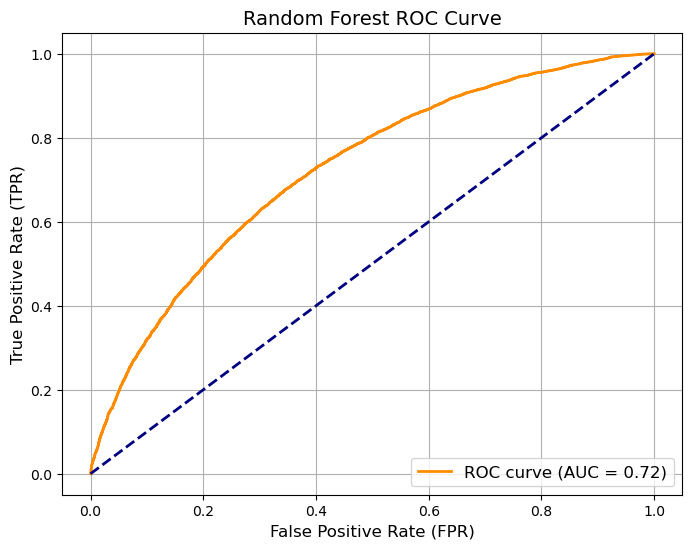


Feature Importance:
               Feature  Importance
3             subGrade    0.171385
2         interestRate    0.151023
1                 term    0.063148
5                  dti    0.051819
16     all_installment    0.045230
19      ficoRange_mean    0.043307
21          rest_Revol    0.041530
17     rest_money_rate    0.038856
23        k-regionCode    0.031559
15        total_income    0.031384
22          k-postCode    0.031176
8            revolUtil    0.029827
0             loanAmnt    0.025999
24   k-employmentTitle    0.025571
18            closeAcc    0.023335
14          CreditLine    0.022378
25             k-title    0.021163
9                   n3    0.020056
13                 n14    0.018846
11                  n6    0.018295
26           k-purpose    0.017003
10                  n5    0.016906
27                   0    0.012301
4     employmentLength    0.011422
28                   1    0.009916
33                   6    0.007778
6   delinquency_2years    0.004461

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, KFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, roc_auc_score,
    roc_curve, auc, confusion_matrix, classification_report
)

# =========================
# 1) 读取数据
# =========================
datarf = pd.read_csv('trainhot37.csv')

X_rf = datarf.drop(['isDefault'], axis=1)
y_rf = datarf['isDefault']

# =========================
# 2) 划分训练/验证集
# =========================
X_train_splitrf, X_valrf, y_train_splitrf, y_valrf = train_test_split(
    X_rf, y_rf, test_size=0.2, random_state=42, stratify=y_rf
)

# =========================
# 3) （可选）5折CV看AUC
# =========================
kf = KFold(n_splits=5, shuffle=True, random_state=525)
cv_auc_scores = []

for i, (train_idx, val_idx) in enumerate(kf.split(X_rf, y_rf), 1):
    X_train_cv, X_val_cv = X_rf.iloc[train_idx], X_rf.iloc[val_idx]
    y_train_cv, y_val_cv = y_rf.iloc[train_idx], y_rf.iloc[val_idx]

    clf_cv = RandomForestClassifier(
        n_estimators=500,
        max_depth=12,
        min_samples_split=10,
        min_samples_leaf=5,
        max_features='sqrt',
        class_weight='balanced',   # 样本不平衡建议
        random_state=42,
        n_jobs=-1
    )
    clf_cv.fit(X_train_cv, y_train_cv)

    y_prob_cv = clf_cv.predict_proba(X_val_cv)[:, 1]
    auc_cv = roc_auc_score(y_val_cv, y_prob_cv)
    cv_auc_scores.append(auc_cv)
    print(f"Fold {i} AUC: {auc_cv:.4f}")

print(f"\nCV AUC Mean: {np.mean(cv_auc_scores):.4f} ± {np.std(cv_auc_scores):.4f}")

# =========================
# 4) 训练随机森林模型
# =========================
clfRF = RandomForestClassifier(
    n_estimators=500,
    max_depth=12,
    min_samples_split=10,
    min_samples_leaf=5,
    max_features='sqrt',
   # class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

clfRF.fit(X_train_splitrf, y_train_splitrf)

# 默认score（accuracy）
score = clfRF.score(X_valrf, y_valrf)
print('\n模型在验证集上的得分(accuracy)：', score)


# =========================
# 7) 特征重要性
# =========================
feature_importances = clfRF.feature_importances_
normalized_importances = feature_importances / feature_importances.sum()

feature_df = pd.DataFrame({
    'Feature': X_train_splitrf.columns,
    'Importance': normalized_importances
}).sort_values(by='Importance', ascending=False)

print("\nFeature Importance:")
print(feature_df)


Threshold: 0.45
Accuracy: 0.673950
Precision: 0.594626
Recall: 0.580875
AUC: 0.724489

Confusion Matrix:
[[8832 3168]
 [3353 4647]]

Classification Report:
              precision    recall  f1-score   support

           0     0.7248    0.7360    0.7304     12000
           1     0.5946    0.5809    0.5877      8000

    accuracy                         0.6740     20000
   macro avg     0.6597    0.6584    0.6590     20000
weighted avg     0.6727    0.6740    0.6733     20000

KS值: 0.3315


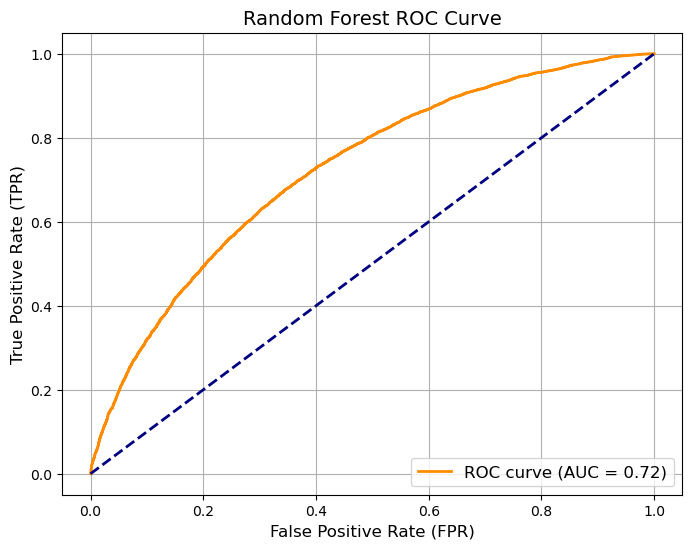

In [7]:
# =========================
# 5) 自定义阈值评估（与你GBM一致）
# =========================
y_val_prob_rf = clfRF.predict_proba(X_valrf)[:, 1]

threshold = 0.45
y_predrf = (y_val_prob_rf >= threshold).astype(int)

accuracyrf = accuracy_score(y_valrf, y_predrf)
precisionrf = precision_score(y_valrf, y_predrf, zero_division=0)
recallrf = recall_score(y_valrf, y_predrf, zero_division=0)
aucrf = roc_auc_score(y_valrf, y_val_prob_rf)

print(f"\nThreshold: {threshold}")
print(f"Accuracy: {accuracyrf:.6f}")
print(f"Precision: {precisionrf:.6f}")
print(f"Recall: {recallrf:.6f}")
print(f"AUC: {aucrf:.6f}")

print("\nConfusion Matrix:")
print(confusion_matrix(y_valrf, y_predrf))

print("\nClassification Report:")
print(classification_report(y_valrf, y_predrf, digits=4))

# =========================
# 6) KS值 + ROC曲线
# =========================
fprrf, tprrf, thresholdsr = roc_curve(y_valrf, y_val_prob_rf)
ks_value = np.max(tprrf - fprrf)
roc_aucrf = auc(fprrf, tprrf)

print(f"KS值: {ks_value:.4f}")

plt.figure(figsize=(8, 6))
plt.plot(fprrf, tprrf, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_aucrf:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate (FPR)', fontsize=12)
plt.ylabel('True Positive Rate (TPR)', fontsize=12)
plt.title('Random Forest ROC Curve', fontsize=14)
plt.legend(loc='lower right', fontsize=12)
plt.grid(True)
plt.show()


## xgboost

### xgboost调参

In [14]:
dataxgboost=pd.read_csv('train30.csv')

In [17]:
#xgboost
X_xg = dataxgboost.drop(['isDefault'], axis=1)
Y_xg = dataxgboost.loc[:, 'isDefault']

kf = KFold(n_splits=5, shuffle=True, random_state=525)
X_train_splitxg, X_valxg, Y_train_splitxg, Y_valxg = train_test_split(X_xg, Y_xg, test_size=0.2)
cv_scores = []
for i, (train_indexxg, val_indexxg) in enumerate(kf.split(X_xg, Y_xg)):
    X_trainxg, Y_trainxg, X_valxg, Y_valxg = X_xg.iloc[train_indexxg], Y_xg.iloc[train_indexxg], X_xg.iloc[val_indexxg], Y_xg.iloc[val_indexxg]
    
    train_matrix_xg = lgb.Dataset(X_trainxg, label=Y_trainxg)
    valid_matrix_xg = lgb.Dataset(X_valxg, label=Y_valxg)

In [133]:
##XGboost调参
from xgboost.sklearn import XGBClassifier
from sklearn.model_selection import GridSearchCV

# 统计训练集正负样本
n_pos = (Y_train_splitxg == 1).sum()
n_neg = (Y_train_splitxg == 0).sum()
spw = n_neg / n_pos

# print("n_neg:", n_neg, " n_pos:", n_pos, " scale_pos_weight:", spw)


# 其余参数
other_params = {'learning_rate': 0.1, 
                'n_estimators': 100, 
                'max_depth': 5, 
                'min_child_weight': 1, 
                'seed': 0,
                'subsample': 0.8, 
                'colsample_bytree': 0.8, 
                'gamma': 0, 
                'reg_alpha': 0, 
                'reg_lambda': 1 }

# 待调参数
param_test1 = {
 'max_depth':list(range(4,9,2)),
 'min_child_weight':list(range(1,6,2))
}

xgb1 = XGBClassifier(**other_params)
# 网格搜索
gs1 = GridSearchCV(xgb1,param_test1,cv = 5,scoring = 'roc_auc',n_jobs = -1,verbose=2)
best_model1=gs1.fit(X_train_splitxg, Y_train_splitxg)
print('最优参数：',best_model1.best_params_)
print('最佳模型得分：',best_model1.best_score_)



#优化gamma
other_params = {'learning_rate': 0.1, 
                'n_estimators': 100, 
                'max_depth': 6, 
                'min_child_weight': 1, 
                'seed': 0,
                'subsample': 0.8, 
                'colsample_bytree': 0.8, 
                'gamma': 0, 
                'reg_alpha': 0, 
                'reg_lambda': 1}


param_test2 = {
'gamma':[0,0.05,0.1,0.2,0.3]
}

xgb2 = XGBClassifier(**other_params,
               eval_metric="aucpr",          # 不平衡时推荐
               scale_pos_weight=spw)
gs2 = GridSearchCV(xgb2,param_test2,cv = 5,scoring = 'roc_auc',n_jobs = -1,verbose=2)
best_model2=gs2.fit(X_train_splitxg, Y_train_splitxg)
print('最优参数：',best_model2.best_params_)
print('最佳模型得分：',best_model2.best_score_)


#优化subsample和colsample_bytree
other_params = {'learning_rate': 0.1, 'n_estimators': 100, 'max_depth': 6, 'min_child_weight': 1, 'seed': 0,
                    'subsample': 0.8, 'colsample_bytree': 0.8, 'gamma': 0, 'reg_alpha': 0, 'reg_lambda': 1}

param_test3 = {
'subsample':[0.6,0.7,0.8,0.9],
'colsample_bytree':[0.6,0.7,0.8,0.9]
}

xgb3 = XGBClassifier(**other_params)
gs3 = GridSearchCV(xgb3,param_test3,cv = 5,scoring = 'roc_auc',n_jobs = -1,verbose=2)
best_model3=gs3.fit(X_train_splitxg, Y_train_splitxg)
print('最优参数：',best_model3.best_params_)
print('最佳模型得分：',best_model3.best_score_)

Fitting 5 folds for each of 9 candidates, totalling 45 fits
最优参数： {'max_depth': 4, 'min_child_weight': 5}
最佳模型得分： 0.7221535729145891
Fitting 5 folds for each of 5 candidates, totalling 25 fits
最优参数： {'gamma': 0.1}
最佳模型得分： 0.7173234985234085
Fitting 5 folds for each of 16 candidates, totalling 80 fits
最优参数： {'colsample_bytree': 0.7, 'subsample': 0.9}
最佳模型得分： 0.7207271361391004


In [134]:
#reg_alpha和reg_lambda
other_params = {'learning_rate': 0.1, 'n_estimators': 100, 'max_depth': 4, 'min_child_weight': 5, 'seed': 0,
                    'subsample': 0.9, 'colsample_bytree': 0.7, 'gamma': 0.2,'reg_alpha': 0, 'reg_lambda': 1}

param_test4 = {
'reg_alpha': [4,5,6,7], 
'reg_lambda': [0,0.01,0.05, 0.1]
}

xgb4 = XGBClassifier(**other_params,
               eval_metric="aucpr",          # 不平衡时推荐
               scale_pos_weight=spw)
gs4 = GridSearchCV(xgb4,param_test4,cv = 5,scoring = 'roc_auc',n_jobs = -1,verbose=2)
best_model4=gs4.fit(X_train_splitxg, Y_train_splitxg)
print('最优参数：',best_model4.best_params_)
print('最佳模型得分：',best_model4.best_score_)

Fitting 5 folds for each of 16 candidates, totalling 80 fits
最优参数： {'reg_alpha': 7, 'reg_lambda': 0}
最佳模型得分： 0.7225834726503277


In [ ]:
#learning_rate和n_estimators
other_params = {'learning_rate': 0.1, 'n_estimators': 100, 'max_depth': 6, 'min_child_weight': 1, 'seed': 0,
                    'subsample': 0.9, 'colsample_bytree': 0.7, 'gamma': 0, 'reg_alpha': 7, 'reg_lambda': 0}

param_test5 = {
'learning_rate': [0.01, 0.05, 0.07, 0.1, 0.2], 
'n_estimators': [100,200,300,400,500]
}

xgb5 = XGBClassifier(**other_params,
               eval_metric="aucpr",          # 不平衡时推荐
               scale_pos_weight=spw)
gs5 = GridSearchCV(xgb5,param_test5,cv = 5,scoring = 'roc_auc',n_jobs = -1,verbose=2)
best_model5=gs5.fit(X_train_splitxg, Y_train_splitxg)
print('最优参数：',best_model5.best_params_)
print('最佳模型得分：',best_model5.best_score_)

### xgboost最终

In [18]:
#最终accuracy
from xgboost.sklearn import XGBClassifier
from sklearn.model_selection import GridSearchCV
clfxg= XGBClassifier(
				learning_rate= 0.01, 
				n_estimators= 500, 
				max_depth= 6, 
				min_child_weight= 1, 
				seed= 0,
                subsample= 0.9, 
                colsample_bytree= 0.7, 
                gamma= 0, 
                reg_alpha= 6, 
                reg_lambda=0.1,
                n_jobs = -1,
               #eval_metric="aucpr" ,        # 不平衡时推荐
               #scale_pos_weight=3
)
             
clfxg.fit(X_train_splitxg, Y_train_splitxg)

clfxg.score(X_valxg, Y_valxg)

0.694

In [19]:
# 训练模型
clfxg.fit(X_train_splitxg, Y_train_splitxg)

# 计算模型得分
score = clfxg.score(X_valxg, Y_valxg)
print(f"Model Score: {score}")

# 获取并打印 feature importances
feature_importances_xg = clfxg.feature_importances_
# 获取特征名
feature_names_xg = X_train_splitxg.columns

# 创建一个 DataFrame 来存储特征名和它们的重要性
feature_df_xg = pd.DataFrame({
    'Feature': feature_names_xg,
    'Importance': feature_importances_xg
})

# 按照 Importance 排序，降序排列
feature_df_xg = feature_df_xg.sort_values(by='Importance', ascending=False)
print(feature_df_xg)

Model Score: 0.694
               Feature  Importance
3             subGrade    0.426726
2         interestRate    0.125999
1                 term    0.097302
5        homeOwnership    0.037334
21      ficoRange_mean    0.021083
6   verificationStatus    0.020672
15                 n14    0.019656
7                  dti    0.019542
19     rest_money_rate    0.017801
11                  n3    0.016315
26   k-employmentTitle    0.016209
23          rest_Revol    0.015640
18     all_installment    0.014454
20            closeAcc    0.014024
25        k-regionCode    0.013424
27             k-title    0.011943
17        total_income    0.010843
8   delinquency_2years    0.010415
0             loanAmnt    0.010349
24          k-postCode    0.009526
16          CreditLine    0.009335
9               pubRec    0.009295
10           revolUtil    0.008204
12                  n5    0.007769
13                  n6    0.007525
4     employmentLength    0.007367
28           k-purpose    0.007363
2

In [24]:
#XGBooost
from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_auc_score

# 模型预测标签

# 1) 预测为正类(1)的概率
y_val_prob = clfxg.predict_proba(X_valxg)[:, 1]

threshold = 0.45
y_predxg = (y_val_prob >= threshold).astype(int)


# y_predxg = clfxg.predict(X_valxg)
# 计算 accuracy
accuracyxg = accuracy_score(Y_valxg, y_predxg)

# 计算 precision
precisionxg = precision_score(Y_valxg, y_predxg)

# 计算 recall
recallxg = recall_score(Y_valxg, y_predxg)

# 计算 AUC (需要使用概率值)
y_pred_probaxg = clfxg.predict_proba(X_valxg)[:, 1]  # 获取属于类别1的概率
aucxg = roc_auc_score(Y_valxg, y_pred_probaxg)

# 输出结果
print(f"Accuracy: {accuracyxg}")
print(f"Precision: {precisionxg}")
print(f"Recall: {recallxg}")
print(f"AUC: {aucxg}")

Accuracy: 0.6876
Precision: 0.6046219542828435
Recall: 0.6082891079100329
AUC: 0.7454873308971661


In [ ]:
###### import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from scipy.stats import ks_2samp


# 计算 ROC 曲线的值
fprxg, tprxg, thresholdsxg = roc_curve(Y_valxg, y_pred_probaxg)

# 计算 AUC（面积下的曲线）
roc_aucxg = auc(fprxg, tprxg)

# 绘制 ROC 曲线
plt.figure(figsize=(8, 6))
plt.plot(fprxg, tprxg, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_aucxg:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')  # 对角线
plt.xlabel('False Positive Rate (FPR)', fontsize=12)
plt.ylabel('True Positive Rate (TPR)', fontsize=12)
plt.title('XgBoost ROC Curve', fontsize=14)
plt.legend(loc='lower right', fontsize=12)
plt.grid(True)
# 显示图形
plt.show()
# 计算 KS (Kolmogorov-Smirnov) 指标
ks_value = max(tprxg - fprxg)
print(f"KS值: {ks_value:.4f}")

## lightgbm

In [28]:
import lightgbm as lgb
from lightgbm import log_evaluation, early_stopping
traincatbost = pd.read_csv('train30.csv')
X_gbm = traincatbost.drop(['isDefault'], axis=1)
y_gbm = traincatbost.loc[:,'isDefault']

kf = KFold(n_splits=5, shuffle=True, random_state=525)
X_train_splitgbm, X_valgbm, y_train_splitgbm, y_valgbm = train_test_split(X_gbm, y_gbm, test_size=0.2)
cv_scores = []
for i, (train_indexgbm, val_indexgbm) in enumerate(kf.split(X_gbm, y_gbm)):
    X_traingbm, y_traingbm, X_valgbm, y_valgbm = X_gbm.iloc[train_indexgbm], y_gbm.iloc[train_indexgbm], X_gbm.iloc[val_indexgbm], y_gbm.iloc[val_indexgbm]
    
    train_matrix_gbm = lgb.Dataset(X_traingbm, label=y_traingbm)
    valid_matrix_gbm = lgb.Dataset(X_valgbm, label=y_valgbm)


In [29]:
import lightgbm as lgb

clfGBM = lgb.LGBMClassifier(
    learning_rate=0.1,  # 初始学习率
    n_estimators=100,  # 树的个数
    max_depth=9,  # 最大深度
    num_leaves=63,  # 最大叶子数
    min_child_samples=20,  # 最小样本数
    seed=0,
    subsample=0.8,  # 样本采样比例
    colsample_bytree=0.9,  # 每棵树的特征采样比例
    reg_alpha=0.7,  # L1 正则化
    reg_lambda=0.1
               #eval_metric="aucpr" ,        # 不平衡时推荐
               #scale_pos_weight=3  
)

# 训练模型
clfGBM.fit(X_train_splitgbm, y_train_splitgbm)

# 计算模型在验证集上的得分
score = clfGBM.score(X_valgbm, y_valgbm)
print('模型在验证集上的得分：', score)

[LightGBM] [Info] Number of positive: 31986, number of negative: 48014
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.005802 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3536
[LightGBM] [Info] Number of data points in the train set: 80000, number of used features: 29
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.399825 -> initscore=-0.406194
[LightGBM] [Info] Start training from score -0.406194
模型在验证集上的得分： 0.72305


In [35]:
# 1) 预测为正类(1)的概率
y_val_prob_gbm = clfGBM.predict_proba(X_valgbm)[:, 1]

threshold = 0.45
y_predgbm = (y_val_prob_gbm >= threshold).astype(int)

# y_predxg = clfxg.predict(X_valxg)

#from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_auc_score
#y_predgbm = clfGBM.predict(X_valgbm)

# 计算 accuracy
accuracygbm = accuracy_score(y_valgbm, y_predgbm)

# 计算 precision
precisiongbm = precision_score(y_valgbm, y_predgbm)

# 计算 recall
recallgbm = recall_score(y_valgbm, y_predgbm)

# 计算 AUC (需要使用概率值)
y_pred_probagbm = clfGBM.predict_proba(X_valgbm)[:, 1]  # 获取属于类别1的概率
aucgbm = roc_auc_score(y_valgbm, y_pred_probagbm)

# 输出结果
print(f"Accuracy: {accuracygbm}")
print(f"Precision: {precisiongbm}")
print(f"Recall: {recallgbm}")
print(f"AUC: {aucgbm}")

Accuracy: 0.71935
Precision: 0.6452468122711779
Recall: 0.6458175385392975
AUC: 0.7837426879748293


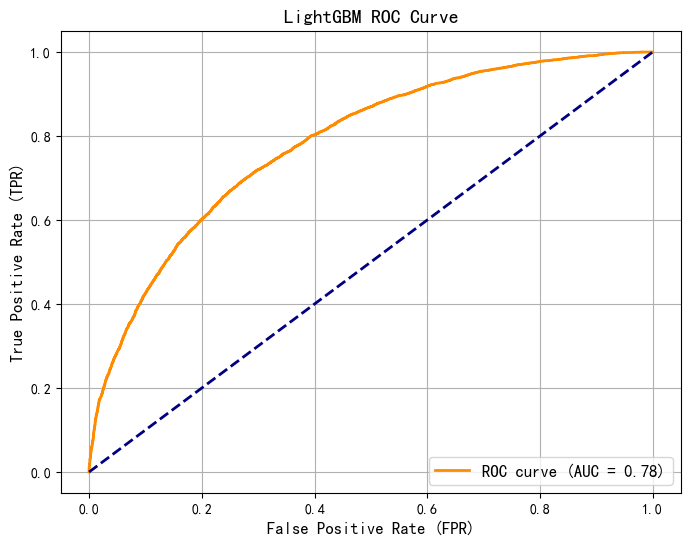

KS值: 0.4217


In [37]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# 计算模型的预测概率
y_pred_probagbm = clfGBM.predict_proba(X_valgbm)[:, 1]  # 获取属于类别1的概率

# 计算 ROC 曲线的值
fprgbm, tprgbm, thresholdsgbm = roc_curve(y_valgbm, y_pred_probagbm)

# 计算 AUC（面积下的曲线）
roc_aucgbm = auc(fprgbm, tprgbm)

# 绘制 ROC 曲线
plt.figure(figsize=(8, 6))
plt.plot(fprgbm, tprgbm, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_aucgbm:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')  # 对角线
plt.xlabel('False Positive Rate (FPR)', fontsize=12)
plt.ylabel('True Positive Rate (TPR)', fontsize=12)
plt.title('LightGBM ROC Curve', fontsize=14)
plt.legend(loc='lower right', fontsize=12)
plt.grid(True)
# 显示图形
plt.show()
# 计算 KS（Kolmogorov-Smirnov）
ks_value = max(tprgbm - fprgbm)
print(f"KS值: {ks_value:.4f}")

In [228]:
# 训练模型
clfGBM.fit(X_train_splitgbm, y_train_splitgbm)

# 计算模型得分
score = clfGBM.score(X_valgbm, y_valgbm)
print(f"Model Score: {score}")

# 获取并打印 feature importances
feature_importances = clfGBM.feature_importances_
# 将 feature importances 归一化
normalized_importances = feature_importances / feature_importances.sum()

# 获取特征名
feature_names = X_train_splitgbm.columns

# 创建一个 DataFrame 来存储特征名和它们的重要性
feature_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': normalized_importances
})

# 按照 Importance 排序，降序排列
feature_df = feature_df.sort_values(by='Importance', ascending=False)
print(feature_df)

[LightGBM] [Info] Number of positive: 31997, number of negative: 48003
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.013189 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3542
[LightGBM] [Info] Number of data points in the train set: 80000, number of used features: 29
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.399962 -> initscore=-0.405621
[LightGBM] [Info] Start training from score -0.405621
Model Score: 0.72105
               Feature  Importance
23          rest_Revol    0.072581
25        k-regionCode    0.071613
7                  dti    0.069839
19     rest_money_rate    0.058226
10           revolUtil    0.054355
17        total_income    0.051129
26   k-employmentTitle    0.050484
2         interestRate    0.047742
24          k-postCode    0.046452
20            closeAcc    0.042419
16          CreditLine    0.041774
21      ficoRange_mean    0.041613
18     all_installment    0.03

## catboost

In [31]:
train30=pd.read_csv('train30.csv')

In [32]:
traincat=train30.drop(['k-postCode', 'k-regionCode', 'k-employmentTitle', 'k-title', 'k-purpose'],axis=1)

In [33]:

Xcat = traincatbost.drop(['isDefault'], axis=1)
ycat = traincatbost.loc[:,'isDefault']

kf = KFold(n_splits=5, shuffle=True, random_state=525)
X_traincat_split, X_valvat, y_traincat_split, y_valcat = train_test_split(Xcat, ycat, test_size=0.2)
cv_scores = []
for i, (train_index, val_index) in enumerate(kf.split(Xcat, ycat)):
    X_traincat, y_traincat, X_valcat, y_valcat = Xcat.iloc[train_index], ycat.iloc[train_index], Xcat.iloc[val_index], ycat.iloc[val_index]
    

from catboost import CatBoostClassifier

In [34]:
clfcatboost = CatBoostClassifier(
	one_hot_max_size=50,
    border_count= 254,
    learning_rate= 0.08,  
    iterations=900,
    depth=6,
    l2_leaf_reg=5,
    bagging_temperature=0.5,
    random_seed=0,
)
             
clfcatboost.fit(X_traincat, y_traincat)
clfcatboost.score(X_valcat, y_valcat)

0:	learn: 0.6800928	total: 195ms	remaining: 2m 55s
1:	learn: 0.6686045	total: 233ms	remaining: 1m 44s
2:	learn: 0.6596409	total: 265ms	remaining: 1m 19s
3:	learn: 0.6517087	total: 295ms	remaining: 1m 6s
4:	learn: 0.6444836	total: 330ms	remaining: 59s
5:	learn: 0.6385536	total: 362ms	remaining: 53.9s
6:	learn: 0.6335691	total: 402ms	remaining: 51.2s
7:	learn: 0.6293534	total: 432ms	remaining: 48.2s
8:	learn: 0.6257095	total: 460ms	remaining: 45.6s
9:	learn: 0.6226023	total: 492ms	remaining: 43.8s
10:	learn: 0.6200586	total: 519ms	remaining: 42s
11:	learn: 0.6177063	total: 550ms	remaining: 40.7s
12:	learn: 0.6156981	total: 580ms	remaining: 39.6s
13:	learn: 0.6139964	total: 609ms	remaining: 38.6s
14:	learn: 0.6123467	total: 636ms	remaining: 37.5s
15:	learn: 0.6107207	total: 660ms	remaining: 36.5s
16:	learn: 0.6094563	total: 687ms	remaining: 35.7s
17:	learn: 0.6083038	total: 715ms	remaining: 35s
18:	learn: 0.6071748	total: 742ms	remaining: 34.4s
19:	learn: 0.6061624	total: 768ms	remaining:

0.68105

In [38]:
# 1) 预测为正类(1)的概率
y_val_prob_cat = clfcatboost.predict_proba(X_valcat)[:, 1]

threshold = 0.45
y_predcat = (y_val_prob_cat >= threshold).astype(int)

# 模型预测标签
#y_predcat = clfcatboost.predict(X_valcat)

# 计算 accuracy
accuracycat = accuracy_score(y_valcat, y_predcat)

# 计算 precision
precisioncat = precision_score(y_valcat, y_predcat)

# 计算 recall
recallcat = recall_score(y_valcat, y_predcat)

# 计算 AUC (需要使用概率值)
y_pred_probacat = clfcatboost.predict_proba(X_valcat)[:, 1]  # 获取属于类别1的概率
auccat = roc_auc_score(y_valcat, y_pred_probacat)

# 输出结果
print(f"Accuracy: {accuracycat}")
print(f"Precision: {precisioncat}")
print(f"Recall: {recallcat}")
print(f"AUC: {auccat}")

Accuracy: 0.6715
Precision: 0.5836445108289768
Recall: 0.5924943138741471
AUC: 0.7250546071744026


In [39]:
# 计算模型在验证集上的得分
score = clfcatboost.score(X_valcat, y_valcat)
print('模型在验证集上的得分：', score)

# 获取并打印 feature importances
feature_importances = clfcatboost.get_feature_importance()

# 将 feature importances 归一化
normalized_importances = feature_importances / feature_importances.sum()

# 获取特征名
feature_names = X_traincat_split.columns

# 创建一个 DataFrame 来存储特征名和它们的重要性
feature_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': normalized_importances
})

# 按照 Importance 排序，降序排列
feature_df = feature_df.sort_values(by='Importance', ascending=False)

print(feature_df)

模型在验证集上的得分： 0.68105
               Feature  Importance
3             subGrade    0.090560
2         interestRate    0.062188
23          rest_Revol    0.059174
7                  dti    0.057985
19     rest_money_rate    0.050314
25        k-regionCode    0.048515
10           revolUtil    0.045712
17        total_income    0.044482
24          k-postCode    0.043658
16          CreditLine    0.039139
26   k-employmentTitle    0.039062
21      ficoRange_mean    0.038735
27             k-title    0.035550
20            closeAcc    0.034275
0             loanAmnt    0.033954
1                 term    0.033378
11                  n3    0.032095
15                 n14    0.028671
28           k-purpose    0.027584
18     all_installment    0.027366
12                  n5    0.027249
5        homeOwnership    0.025468
13                  n6    0.025057
4     employmentLength    0.011880
6   verificationStatus    0.011352
8   delinquency_2years    0.010905
9               pubRec    0.007987


In [40]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# 计算模型的预测概率
y_pred_probacat = clfcatboost.predict_proba(X_valcat)[:, 1]  # 获取属于类别1的概率

# 计算 ROC 曲线的值
fprcat, tprcat, thresholds = roc_curve(y_valcat, y_pred_probacat)

# 计算 AUC（面积下的曲线）
roc_auccat = auc(fprcat, tprcat)
ks_value = max(tprcat - fprcat)
print(f"KS值: {ks_value:.4f}")


KS值: 0.3257


## adaboost

In [41]:
from sklearn.ensemble import AdaBoostClassifier
X_ada = dataxgboost.drop(['isDefault'], axis=1)
Y_ada = dataxgboost.loc[:, 'isDefault']

kf = KFold(n_splits=5, shuffle=True, random_state=525)
X_train_splitada, X_valada, Y_train_splitada, Y_valada = train_test_split(X_ada, Y_ada, test_size=0.2)
cv_scores = []
for i, (train_indexada, val_indexada) in enumerate(kf.split(X_ada, Y_ada)):
    X_trainada, Y_trainada, X_valada, Y_valada = X_ada.iloc[train_indexada], Y_ada.iloc[train_indexada], X_ada.iloc[val_indexada], Y_ada.iloc[val_indexada]
    
    train_matrix_ada = lgb.Dataset(X_trainada, label=Y_trainada)
    valid_matrix_ada = lgb.Dataset(X_valada, label=Y_valada)
    

In [43]:
# 其余参数
from sklearn.tree import DecisionTreeClassifier
other_params = {'n_estimators': 100, 
                'learning_rate': 0.1, 
                'algorithm': 'SAMME.R'}

# 待调参数
param_test1 = {
    'n_estimators': [50, 100, 200],
    'learning_rate': [0.01, 0.1, 1]
}

ada1 = AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=1), **other_params)

# 网格搜索
gs1 = GridSearchCV(ada1, param_test1, cv=5, scoring='roc_auc', n_jobs=-1, verbose=2)
best_model1 = gs1.fit(X_train_splitada, Y_train_splitada)

print('最优参数：', best_model1.best_params_)
print('最佳模型得分：', best_model1.best_score_)

Fitting 5 folds for each of 9 candidates, totalling 45 fits
最优参数： {'learning_rate': 1, 'n_estimators': 200}
最佳模型得分： 0.7212951392124338


In [45]:
clfadaboost = AdaBoostClassifier(
n_estimators=200,learning_rate=1,algorithm='SAMME.R')
# 训练模型
clfadaboost.fit(X_train_splitada, Y_train_splitada)

# 计算模型评分
score = clfadaboost.score(X_valada, Y_valada)
print(f"模型评分: {score}")

模型评分: 0.67815


In [46]:
score = clfadaboost.score(X_valada, Y_valada)
print('模型在验证集上的得分：', score)

# 获取并打印 feature importances
feature_importances = clfadaboost.feature_importances_

# 将 feature importances 归一化
normalized_importances = feature_importances / feature_importances.sum()

# 获取特征名
feature_names = X_train_splitada.columns

# 创建一个 DataFrame 来存储特征名和它们的重要性
feature_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': normalized_importances
})

# 按照 Importance 排序，降序排列
feature_df = feature_df.sort_values(by='Importance', ascending=False)
print(feature_df)

模型在验证集上的得分： 0.67815
               Feature  Importance
3             subGrade       0.130
23          rest_Revol       0.075
24          k-postCode       0.065
25        k-regionCode       0.055
7                  dti       0.050
20            closeAcc       0.050
18     all_installment       0.050
27             k-title       0.045
17        total_income       0.040
2         interestRate       0.040
26   k-employmentTitle       0.040
19     rest_money_rate       0.040
0             loanAmnt       0.035
10           revolUtil       0.035
11                  n3       0.035
21      ficoRange_mean       0.035
28           k-purpose       0.030
16          CreditLine       0.025
15                 n14       0.025
8   delinquency_2years       0.025
5        homeOwnership       0.020
13                  n6       0.010
12                  n5       0.010
6   verificationStatus       0.010
14                 n13       0.010
1                 term       0.005
22         rest_pubRec       0.005


In [47]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_auc_score
# 1) 预测为正类(1)的概率
y_val_prob_ada = clfadaboost.predict_proba(X_valada)[:, 1]

threshold = 0.4998
Y_predada = (y_val_prob_ada >= threshold).astype(int)
# 模型预测标签
#Y_predada = clfadaboost.predict(X_valada)

# 计算 accuracy
accuracyada = accuracy_score(Y_valada, Y_predada)

# 计算 precision
precisionada = precision_score(Y_valada, Y_predada)

# 计算 recall
recallada = recall_score(Y_valada, Y_predada)

# 计算 AUC (需要使用概率值)
Y_pred_probaada = clfadaboost.predict_proba(X_valada)[:, 1]  # 获取属于类别1的概率
aucada = roc_auc_score(Y_valada, Y_pred_probaada)

# 输出结果
print(f"Accuracy: {accuracyada}")
print(f"Precision: {precisionada}")
print(f"Recall: {recallada}")
print(f"AUC: {aucada}")

Accuracy: 0.6737
Precision: 0.5895252837977296
Recall: 0.5774576699519838
AUC: 0.7267901892222076


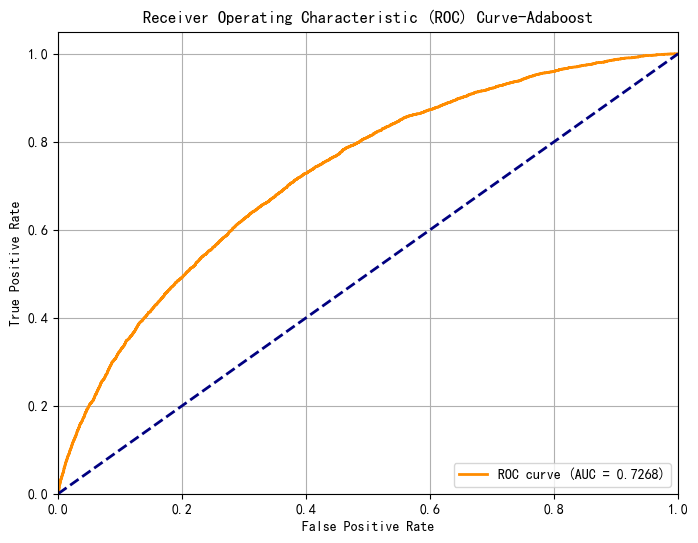

AUC: 0.73


In [48]:

# 计算 ROC 曲线的值
fprada, tprada, thresholdsada = roc_curve(Y_valada, Y_pred_probaada)

# 计算 AUC（面积下的曲线）
roc_aucada = auc(fprada, tprada)

# 绘制 ROC 曲线
plt.figure(figsize=(8, 6))
plt.plot(fprada, tprada, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_aucada:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve-Adaboost')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

# 输出 AUC 分数
print(f"AUC: {roc_aucada:.2f}")

In [49]:
ks_value = max(tprada - fprada)
print(f"KS值: {ks_value:.4f}")

KS值: 0.3312


## stacking

In [280]:
#stacking
from mlxtend.classifier import StackingClassifier
from sklearn.metrics import auc
sclf = StackingClassifier(classifiers=[clfGBM, clfcatboost, clfadaboost], 
						  use_probas=True,
                          meta_classifier=clfxg)
                          
sclf.fit(X_train_splitada, Y_train_splitada)
stackingpre =sclf.predict_proba(X_valada)[:,1]
stackingfpr, stackingtpr, stackingthresholds = roc_curve(Y_valada, stackingpre)
stackingscore = auc(stackingfpr, stackingtpr)
print(stackingscore)

[LightGBM] [Info] Number of positive: 32099, number of negative: 47901
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.018506 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3546
[LightGBM] [Info] Number of data points in the train set: 80000, number of used features: 29
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.401238 -> initscore=-0.400312
[LightGBM] [Info] Start training from score -0.400312
0:	learn: 0.6799511	total: 39.1ms	remaining: 35.1s
1:	learn: 0.6686985	total: 81.8ms	remaining: 36.7s
2:	learn: 0.6594269	total: 117ms	remaining: 35.1s
3:	learn: 0.6520994	total: 152ms	remaining: 34s
4:	learn: 0.6454670	total: 291ms	remaining: 52.1s
5:	learn: 0.6397267	total: 337ms	remaining: 50.2s
6:	learn: 0.6349476	total: 371ms	remaining: 47.3s
7:	learn: 0.6307995	total: 399ms	remaining: 44.5s
8:	learn: 0.6272472	total: 428ms	remaining: 42.3s
9:	learn: 0.6240154	total: 515ms	remaining: 45.8s
10:	le

In [281]:
# 模型预测标签
Y_predstacking = sclf.predict(X_valada)

# 计算 accuracy
accuracystacking = accuracy_score(Y_valada, Y_predstacking)

# 计算 precision
precisionstacking = precision_score(Y_valada, Y_predstacking)

# 计算 recall
recallstacking = recall_score(Y_valada, Y_predstacking)

# 计算 AUC (需要使用概率值)
Y_pred_probastacking = sclf.predict_proba(X_valada)[:, 1]  # 获取属于类别1的概率
aucstacking = roc_auc_score(Y_valada, Y_pred_probastacking)

# 输出结果
print(f"Accuracy: {accuracystacking}")
print(f"Precision: {precisionstacking}")
print(f"Recall: {recallstacking}")
print(f"AUC: {aucstacking}")

Accuracy: 0.76855
Precision: 0.72866490324377
Recall: 0.6613596158706091
AUC: 0.8370350705798069


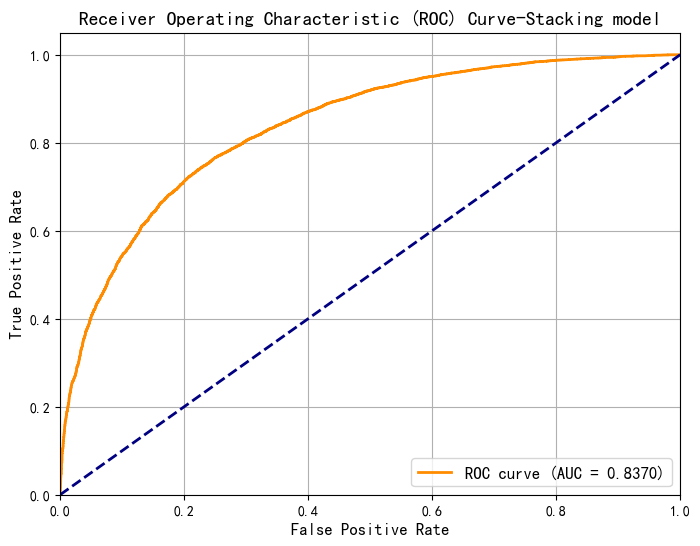

KS值: 0.5168


In [282]:
# 绘制 stackingROC 曲线
plt.figure(figsize=(8, 6))
plt.plot(stackingfpr, stackingtpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {stackingscore:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve-Stacking model')
plt.legend(loc='lower right')
plt.grid(True)
plt.savefig("ROC_Curves_stacking.png", dpi=300, bbox_inches="tight")  # 保存图片
plt.show()  # 显示（可选）
ks_value = max(stackingtpr - stackingfpr)
print(f"KS值: {ks_value:.4f}")

## stacking2

In [50]:
#stacking
from mlxtend.classifier import StackingClassifier
from sklearn.metrics import auc
sclf = StackingClassifier(classifiers=[clfGBM, clfcatboost, clfadaboost,clfxg], 
						  use_probas=True,
                          meta_classifier=clf_cv)
                          
sclf.fit(X_train_splitada, Y_train_splitada)
stackingpre =sclf.predict_proba(X_valada)[:,1]
stackingfpr, stackingtpr, stackingthresholds = roc_curve(Y_valada, stackingpre)
stackingscore = auc(stackingfpr, stackingtpr)
print(stackingscore)

[LightGBM] [Info] Number of positive: 32106, number of negative: 47894
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.008260 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3539
[LightGBM] [Info] Number of data points in the train set: 80000, number of used features: 29
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.401325 -> initscore=-0.399947
[LightGBM] [Info] Start training from score -0.399947
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
0:	learn: 0.6796607	total: 27.7ms	remaining: 24.9s
1:	learn: 0.6685243	total: 53.5ms	remaining: 24s
2:	learn: 0.6593005	total: 77.3ms	remaining: 23.1s
3:	learn: 0.6514835	total: 101ms	remaining: 22.6s
4:	learn: 0.6450056	total: 123ms	remaining: 22s
5:	learn: 0.6394684	total: 147ms	remaining: 21.8s
6:	learn: 0.6344443	total: 172ms	remaining: 21.9s
7:	learn: 0.6303465	total: 200ms	remaining: 22.3s
8:	learn: 0.6270434	total: 225ms

In [51]:
# 模型预测标签
Y_predstacking = sclf.predict(X_valada)

# 计算 accuracy
accuracystacking = accuracy_score(Y_valada, Y_predstacking)

# 计算 precision
precisionstacking = precision_score(Y_valada, Y_predstacking)

# 计算 recall
recallstacking = recall_score(Y_valada, Y_predstacking)

# 计算 AUC (需要使用概率值)
Y_pred_probastacking = sclf.predict_proba(X_valada)[:, 1]  # 获取属于类别1的概率
aucstacking = roc_auc_score(Y_valada, Y_pred_probastacking)

# 输出结果
print(f"Accuracy: {accuracystacking}")
print(f"Precision: {precisionstacking}")
print(f"Recall: {recallstacking}")
print(f"AUC: {aucstacking}")

Accuracy: 0.79195
Precision: 0.7233662659207237
Recall: 0.7678797068486227
AUC: 0.8737784453184492


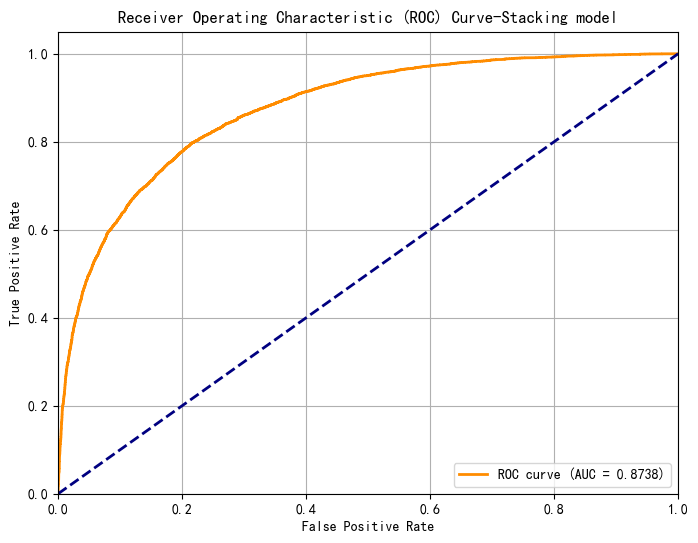

KS值: 0.5819


In [52]:
# 绘制 stackingROC 曲线
plt.figure(figsize=(8, 6))
plt.plot(stackingfpr, stackingtpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {stackingscore:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve-Stacking model')
plt.legend(loc='lower right')
plt.grid(True)
plt.savefig("ROC_Curves_stacking.png", dpi=300, bbox_inches="tight")  # 保存图片
plt.show()  # 显示（可选）
ks_value = max(stackingtpr - stackingfpr)
print(f"KS值: {ks_value:.4f}")

In [67]:
import matplotlib.pyplot as plt
#所有图
# 设置全局字体和样式（可选）
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['legend.fontsize'] = 12

# 创建2x2子图布局
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(9, 12))


models = [
    ('XGBoost', fprxg, tprxg, roc_aucxg),
    ('LightGBM', fprgbm, tprgbm, roc_aucgbm),
    ('CatBoost', fprcat, tprcat, roc_auccat),
    ('AdaBoost', fprada, tprada, roc_aucada),
    ('RandomForest', fprrf,tprrf,roc_aucrf),
    ('Stacking Model',stackingfpr,stackingtpr,aucstacking)
]

# 遍历每个子图并绘制对应的ROC曲线
for ax, (name, fpr, tpr, auc) in zip(axes.flat, models):
    ax.plot(fpr, tpr, color='darkorange', lw=2, label=f'AUC = {auc:.4f}')
    ax.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')  # 对角线
    ax.set_xlabel('False Positive Rate (FPR)')
    ax.set_ylabel('True Positive Rate (TPR)')
    ax.set_title(f'ROC Curve - {name}')
    ax.legend(loc='lower right')
    ax.grid(True)




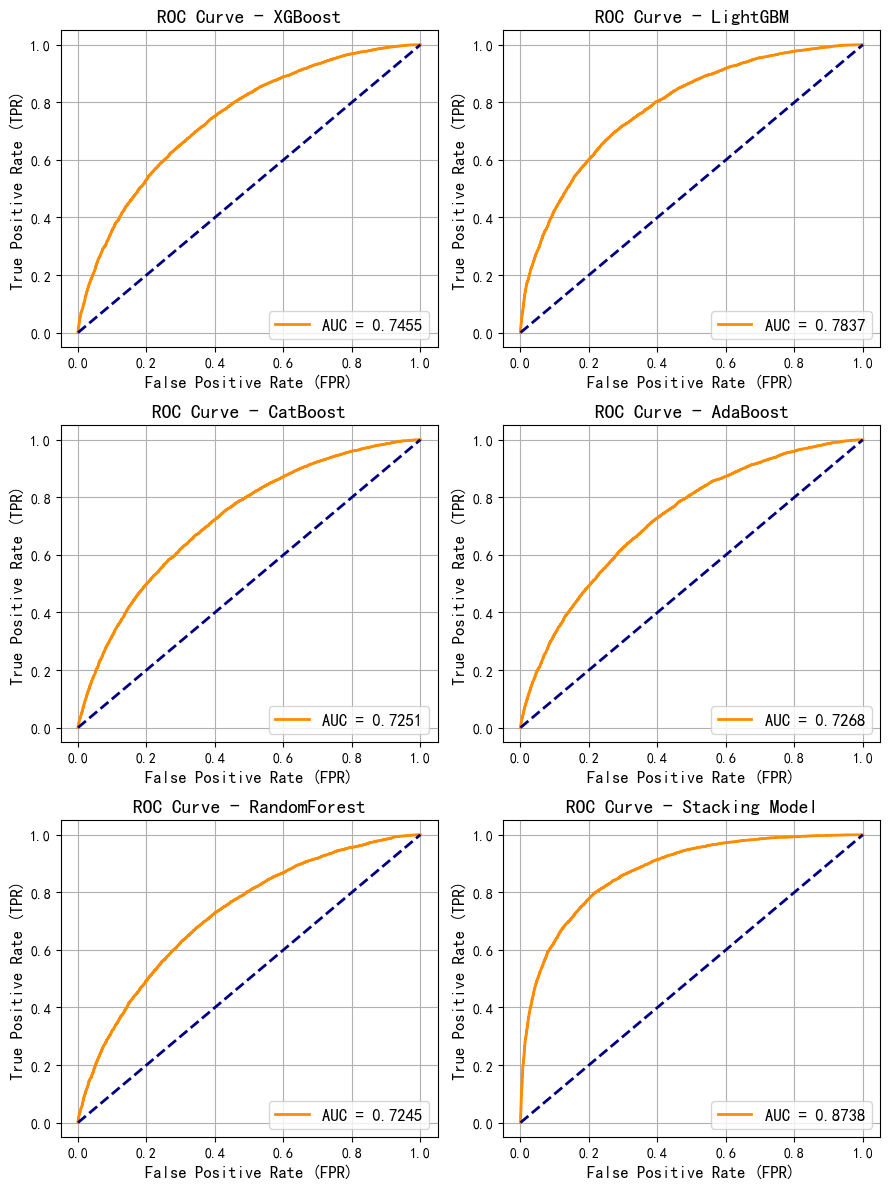

In [68]:

plt.tight_layout()
plt.savefig("ROC_Curves.png", dpi=300, bbox_inches="tight") 
plt.show()  # 显示（可选）

# sharp

<Figure size 640x480 with 0 Axes>

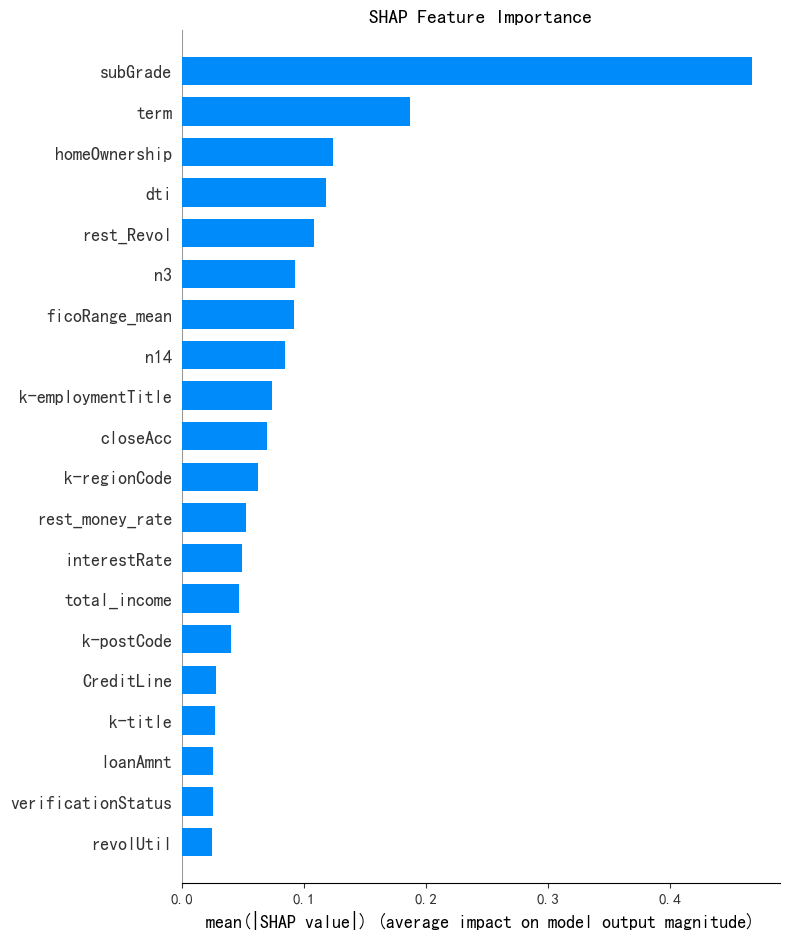

In [71]:
# 如果没安装 shap，请先安装：
# pip install shap

import shap
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# =========================
# 1) 计算 SHAP 值
# =========================
# 对树模型（GBM/XGBoost/LightGBM）推荐 TreeExplainer
explainer = shap.TreeExplainer(clfGBM)

# 说明：
# 对二分类模型，shap_values 可能返回：
# - 一个数组 (n_samples, n_features)，或
# - 一个列表 [class0, class1]
shap_values_raw = explainer.shap_values(X_valgbm)

if isinstance(shap_values_raw, list):
    # 取正类(1)解释
    shap_values = shap_values_raw[1]
    expected_value = explainer.expected_value[1] if isinstance(explainer.expected_value, (list, np.ndarray)) else explainer.expected_value
else:
    shap_values = shap_values_raw
    expected_value = explainer.expected_value[1] if isinstance(explainer.expected_value, (list, np.ndarray)) else explainer.expected_value

# =========================
# 2) 全局重要性 Bar 图
# =========================
plt.figure()
shap.summary_plot(shap_values, X_valgbm, plot_type="bar", show=False)
plt.title("SHAP Feature Importance")
plt.tight_layout()
plt.show()
plt.savefig("SHAP Feature Importance", dpi=300, bbox_inches="tight")



<Figure size 640x480 with 0 Axes>

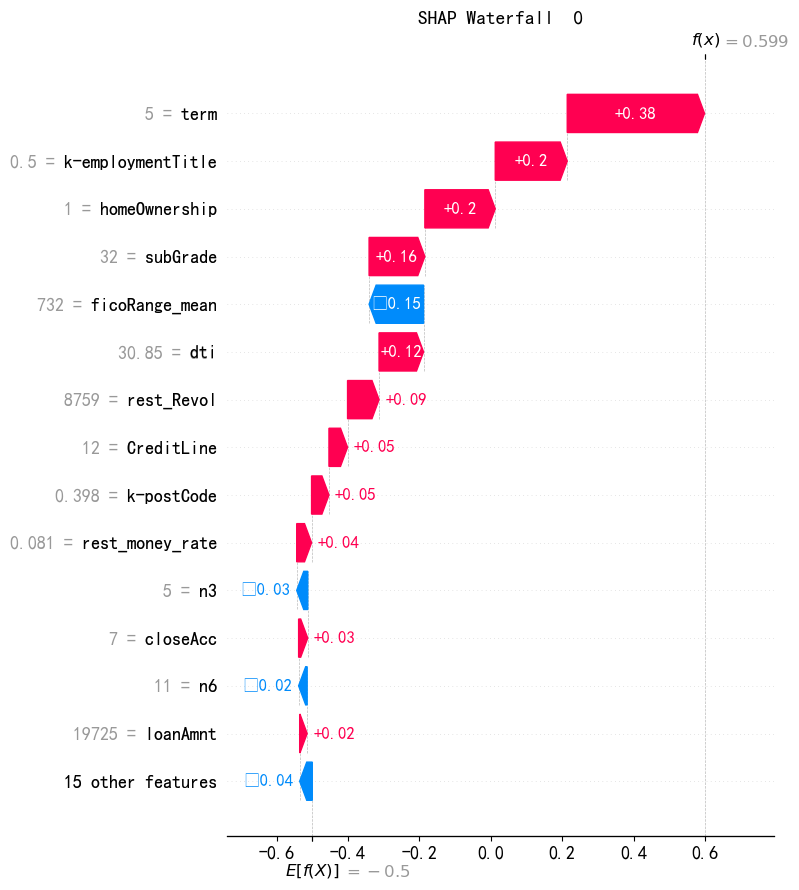

In [72]:
# =========================
# 3) 单样本瀑布图（Waterfall）
# =========================
# 选一个样本，例如第0行；你也可以改成风险最高样本
row_idx = 0

# 构造 Explanation（新版本 shap 推荐）
exp = shap.Explanation(
    values=shap_values[row_idx],
    base_values=expected_value,
    data=X_valgbm.iloc[row_idx].values,
    feature_names=X_valgbm.columns.tolist()
)

plt.figure()
shap.plots.waterfall(exp, max_display=15, show=False)
plt.title(f"SHAP Waterfall  {row_idx}")
plt.tight_layout()
plt.show()
plt.savefig(f"SHAP Waterfall  {row_idx}", dpi=300, bbox_inches="tight")
